# Final Engineering Results
Identification of the Pareto Optimal designs and selection of the best trade-off candidate from the experimental dataset.

Loaded 92 samples from Elips0
Selection Logic: Min Volume with Strength >= 70.0 kN

--- OPTIMAL DESIGN (CATEGORY 0) ---
ID: Specimen_47
Strength: 71.20 kN
Volume:   213.28 mm3
Geometry (a_i): [5.0, 6.0, 7.0, 8.0, 9.0, 11.0]
Geometry (b_i): [5, 6.0, 7.0, 8.0, 9.0, 10.0]


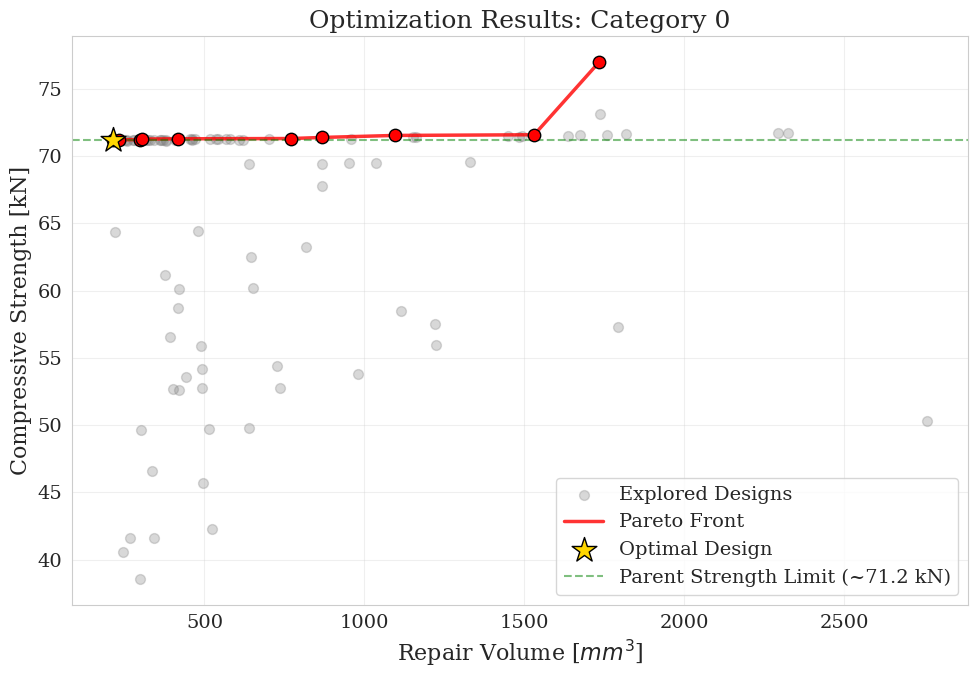

In [7]:
# %% [markdown]
# # Final Engineering Results (Physics-Based Selection)
# Logic: Since strength saturates at the parent limit (~71.2 kN), the 'Best' design is defined as the Minimum Volume configuration that achieves full strength recovery (> 70 kN).

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# --- CONFIGURATION ---
sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": (10, 7)
})

# Load Config
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# --- HELPER FUNCTIONS ---

def calculate_volume(df, ply_thickness):
    """Calculates geometric volume (mm^3)."""
    a_cols = [c for c in df.columns if c.startswith('a_ply')]
    b_cols = [c for c in df.columns if c.startswith('b_ply')]
    areas = np.pi * df[a_cols].values * df[b_cols].values
    return np.sum(areas, axis=1) * ply_thickness

def get_pareto_front(df):
    """Identifies Pareto efficient points."""
    costs = df[['Volume_mm3', 'Strength']].values.copy()
    costs[:, 1] = -costs[:, 1] 
    
    is_efficient = np.arange(costs.shape[0])
    n_points = costs.shape[0]
    next_point_index = 0
    
    while next_point_index < len(costs):
        nondominated_point_mask = np.any(costs < costs[next_point_index], axis=1)
        nondominated_point_mask[next_point_index] = True
        is_efficient = is_efficient[nondominated_point_mask]
        costs = costs[nondominated_point_mask]
        next_point_index = np.sum(nondominated_point_mask[:next_point_index]) + 1
        
    mask = np.zeros(n_points, dtype=bool)
    mask[is_efficient] = True
    return mask

def find_best_physics_design(df_pareto, strength_threshold=70.0):
    """
    Finds the Best Design based on Physical Saturation.
    Criteria:
    1. Must have Strength >= Threshold (Full Recovery).
    2. Minimize Volume among those candidates.
    """
    # Filter for full strength recovery
    high_strength = df_pareto[df_pareto['Strength'] >= strength_threshold]
    
    if len(high_strength) > 0:
        # Pick smallest volume among the strong ones
        best_design = high_strength.sort_values('Volume_mm3').iloc[0]
        print(f"Selection Logic: Min Volume with Strength >= {strength_threshold} kN")
    else:
        # Fallback: Just pick the absolute strongest point found
        best_design = df_pareto.sort_values('Strength', ascending=False).iloc[0]
        print(f"Selection Logic: Fallback (Max Strength) - Threshold {strength_threshold} kN not met.")
        
    return best_design

# --- EXECUTION FOR CATEGORY 0 ---
CATEGORY = 0
file_path = 'Data_v4.xlsx'
sheet_name = f'Elips{CATEGORY}'

# 1. Load Data
try:
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    df = df.dropna(subset=['Strength']) 
    print(f"Loaded {len(df)} samples from {sheet_name}")
except FileNotFoundError:
    print(f"Error: File '{file_path}' not found.")
    df = pd.DataFrame()

if not df.empty:
    # 2. Calculate Volume (Corrected with Ply Thickness)
    ply_thickness = config['OPTIMIZATION']['THICKNESS_CONSTANT']
    if 'Volume' not in df.columns or df['Volume'].isna().all():
        df['Volume_mm3'] = calculate_volume(df, ply_thickness=ply_thickness)
    else:
        df['Volume_mm3'] = df['Volume']

    # 3. Identify Pareto Front
    df['is_pareto'] = get_pareto_front(df)
    pareto_set = df[df['is_pareto']].sort_values('Volume_mm3')

    # 4. Find Best Candidate (Physics Strategy)
    # Threshold set to 70.0 kN based on parent strength saturation ~71.2
    best_design = find_best_physics_design(pareto_set, strength_threshold=70.0)

    print(f"\n--- OPTIMAL DESIGN (CATEGORY {CATEGORY}) ---")
    print(f"ID: {best_design.get('Specimen_ID', 'Unknown')}")
    print(f"Strength: {best_design['Strength']:.2f} kN")
    print(f"Volume:   {best_design['Volume_mm3']:.2f} mm3")
    print("Geometry (a_i):", [best_design[f'a_ply{i}'] for i in range(1,7)])
    print("Geometry (b_i):", [best_design[f'b_ply{i}'] for i in range(1,7)])

    # --- PLOTTING ---
    plt.figure(figsize=(10, 7))

    # Plot All Points
    plt.scatter(df['Volume_mm3'], df['Strength'], 
                c='gray', alpha=0.3, s=50, label='Explored Designs')

    # Plot Pareto Front
    plt.plot(pareto_set['Volume_mm3'], pareto_set['Strength'], 
             'r-', lw=2.5, alpha=0.8, label='Pareto Front')
    plt.scatter(pareto_set['Volume_mm3'], pareto_set['Strength'], 
                c='red', s=80, edgecolors='k', zorder=5)

    # Highlight Best Point
    plt.scatter(best_design['Volume_mm3'], best_design['Strength'], 
                c='gold', marker='*', s=350, edgecolors='k', zorder=10, 
                label='Optimal Design')
    
    # Draw Threshold Line
    plt.axhline(y=71.2, color='green', linestyle='--', alpha=0.5, label='Parent Strength Limit (~71.2 kN)')

    plt.xlabel('Repair Volume [$mm^3$]')
    plt.ylabel('Compressive Strength [kN]')
    plt.title(f'Optimization Results: Category {CATEGORY}')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'final_result_cat{CATEGORY}_physics.png', dpi=300)
    plt.show()

Loaded 78 samples from Elips1
Selection Logic: Min Volume with Strength >= 70.0 kN

--- OPTIMAL DESIGN (CATEGORY 1) ---
ID: Specimen_87
Strength: 71.20 kN
Volume:   259.45 mm3
Ratio R:  0.2744 kN/mm3
Geometry (a_i): [5.0, 6.0, 7.0, 10.0, 11.0, 12.0]
Geometry (b_i): [5, 6.0, 7.0, 8.0, 10.0, 12.0]


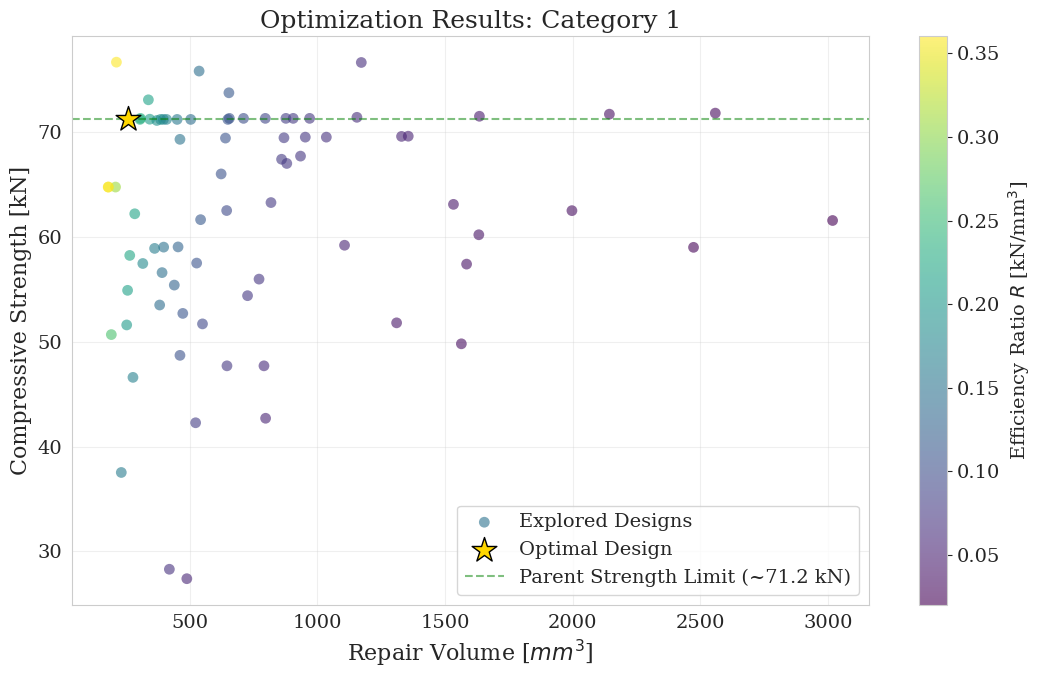

In [35]:
# %% [markdown]
# # Final Engineering Results (Physics-Based Selection with Efficiency Analysis)
# Logic: Since strength saturates at the parent limit (~71.2 kN), the 'Best' design is defined as the Minimum Volume configuration that achieves full strength recovery (> 70 kN).
# We also analyze the Structural Efficiency Ratio (R = Strength / Volume).

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# --- CONFIGURATION ---
sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": (11, 8) # Slightly wider for colorbar
})

# Load Config
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# --- HELPER FUNCTIONS ---

def calculate_volume(df, ply_thickness):
    """Calculates geometric volume (mm^3)."""
    a_cols = [c for c in df.columns if c.startswith('a_ply')]
    b_cols = [c for c in df.columns if c.startswith('b_ply')]
    areas = np.pi * df[a_cols].values * df[b_cols].values
    return np.sum(areas, axis=1) * ply_thickness

def get_pareto_front(df):
    """Identifies Pareto efficient points."""
    costs = df[['Volume_mm3', 'Strength']].values.copy()
    costs[:, 1] = -costs[:, 1] 
    
    is_efficient = np.arange(costs.shape[0])
    n_points = costs.shape[0]
    next_point_index = 0
    
    while next_point_index < len(costs):
        nondominated_point_mask = np.any(costs < costs[next_point_index], axis=1)
        nondominated_point_mask[next_point_index] = True
        is_efficient = is_efficient[nondominated_point_mask]
        costs = costs[nondominated_point_mask]
        next_point_index = np.sum(nondominated_point_mask[:next_point_index]) + 1
        
    mask = np.zeros(n_points, dtype=bool)
    mask[is_efficient] = True
    return mask

def find_best_physics_design(df_pareto, strength_threshold=70.0):
    """
    Finds the Best Design based on Physical Saturation.
    Criteria:
    1. Must have Strength >= Threshold (Full Recovery).
    2. Minimize Volume among those candidates.
    """
    # Filter for full strength recovery
    high_strength = df_pareto[df_pareto['Strength'] >= strength_threshold]

    high_strength = high_strength[high_strength['Strength'] <= 73]
    
    if len(high_strength) > 0:
        # Pick smallest volume among the strong ones
        best_design = high_strength.sort_values('Volume_mm3').iloc[0]
        print(f"Selection Logic: Min Volume with Strength >= {strength_threshold} kN")
    else:
        # Fallback: Just pick the absolute strongest point found
        best_design = df_pareto.sort_values('Strength', ascending=False).iloc[0]
        print(f"Selection Logic: Fallback (Max Strength) - Threshold {strength_threshold} kN not met.")
        
    return best_design

# --- EXECUTION FOR CATEGORY 0 ---
CATEGORY = 1
file_path = 'Data_v4.xlsx'
sheet_name = f'Elips{CATEGORY}'

# 1. Load Data
try:
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    df = df.dropna(subset=['Strength']) 
    print(f"Loaded {len(df)} samples from {sheet_name}")
except FileNotFoundError:
    print(f"Error: File '{file_path}' not found.")
    df = pd.DataFrame()

if not df.empty:
    # 2. Calculate Volume (Corrected with Ply Thickness)
    ply_thickness = config['OPTIMIZATION']['THICKNESS_CONSTANT']
    if 'Volume' not in df.columns or df['Volume'].isna().all():
        df['Volume_mm3'] = calculate_volume(df, ply_thickness=ply_thickness)
    else:
        df['Volume_mm3'] = df['Volume']

    # 3. Calculate Ratio R
    df['Ratio'] = df['Strength'] / df['Volume_mm3']

    # 4. Identify Pareto Front
    df['is_pareto'] = get_pareto_front(df)
    pareto_set = df[df['is_pareto']].sort_values('Volume_mm3')

    # 5. Find Best Candidate (Physics Strategy)
    # Threshold set to 70.0 kN based on parent strength saturation ~71.2
    best_design = find_best_physics_design(df, strength_threshold=70.0)

    print(f"\n--- OPTIMAL DESIGN (CATEGORY {CATEGORY}) ---")
    print(f"ID: {best_design.get('Specimen_ID', 'Unknown')}")
    print(f"Strength: {best_design['Strength']:.2f} kN")
    print(f"Volume:   {best_design['Volume_mm3']:.2f} mm3")
    print(f"Ratio R:  {best_design['Ratio']:.4f} kN/mm3")
    print("Geometry (a_i):", [best_design[f'a_ply{i}'] for i in range(1,7)])
    print("Geometry (b_i):", [best_design[f'b_ply{i}'] for i in range(1,7)])

    # --- PLOTTING ---
    plt.figure(figsize=(11, 7))

    # Plot All Points - Color mapped by Ratio R
    sc = plt.scatter(df['Volume_mm3'], df['Strength'], 
                     c=df['Ratio'], cmap='viridis', 
                     alpha=0.6, s=60, edgecolors='none', label='Explored Designs')
    
    # Add Colorbar for R
    cbar = plt.colorbar(sc)
    cbar.set_label('Efficiency Ratio $R$ [kN/mm$^3$]', fontsize=14)

    # # Plot Pareto Front (Line)
    # plt.plot(pareto_set['Volume_mm3'], pareto_set['Strength'], 
    #          'r-', lw=2.5, alpha=0.8, label='Pareto Front')
    
    # # Plot Pareto Points (Dots - Keep Red for visibility or match colormap?)
    # # Keeping red to distinctively mark the front
    # plt.scatter(pareto_set['Volume_mm3'], pareto_set['Strength'], 
    #             c='red', s=80, edgecolors='k', zorder=5)

    # Highlight Best Point (Star)
    plt.scatter(best_design['Volume_mm3'], best_design['Strength'], 
                c='gold', marker='*', s=350, edgecolors='k', zorder=10, 
                label='Optimal Design')
    
    # Draw Threshold Line
    plt.axhline(y=71.2, color='green', linestyle='--', alpha=0.5, label='Parent Strength Limit (~71.2 kN)')

    plt.xlabel('Repair Volume [$mm^3$]')
    plt.ylabel('Compressive Strength [kN]')
    plt.title(f'Optimization Results: Category {CATEGORY}')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'final_result_cat{CATEGORY}_physics.png', dpi=300)
    plt.show()

Loaded 78 samples from Elips1
Selection Logic: Min Volume with Strength >= 70.0 kN

--- OPTIMAL DESIGN (CATEGORY 1) ---
ID: Specimen_10
Strength: 76.66 kN
Volume:   212.79 mm3
Geometry (a_i): [6.3, 7.5, 8.8, 10.0, 11.3, 12.6]
Geometry (b_i): [5, 5.5, 6.0, 6.5, 7.0, 7.5]


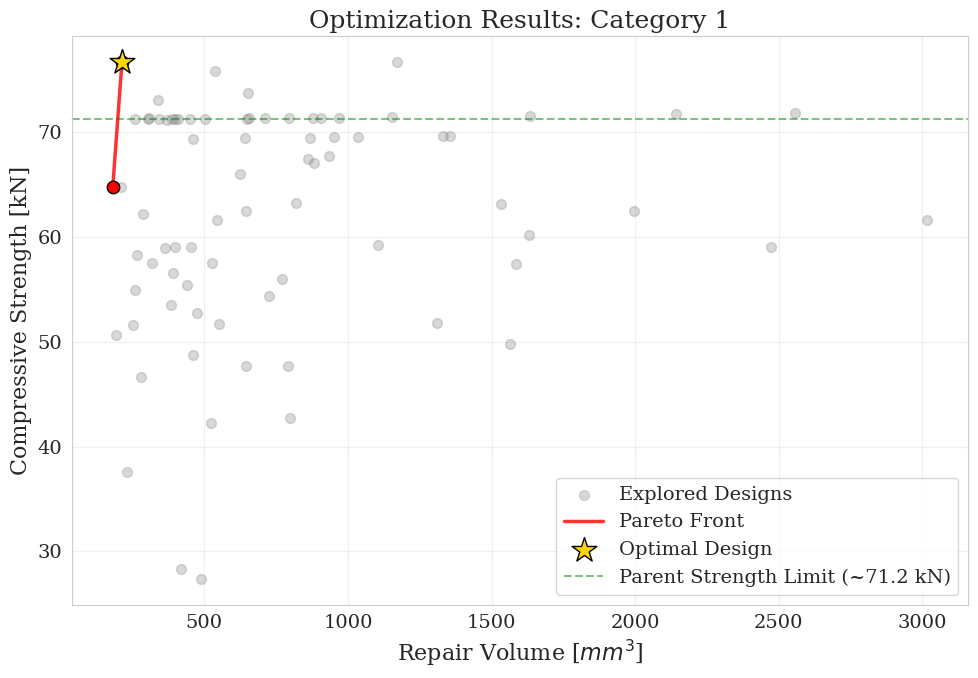

In [8]:
# %% [markdown]
# # Final Engineering Results (Physics-Based Selection) - Category 1
# Logic: Since strength saturates at the parent limit (~71.2 kN), the 'Best' design is defined as the Minimum Volume configuration that achieves full strength recovery (> 70 kN).

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# --- CONFIGURATION ---
sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": (10, 7)
})

# Load Config
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# --- HELPER FUNCTIONS ---

def calculate_volume(df, ply_thickness):
    """Calculates geometric volume (mm^3)."""
    a_cols = [c for c in df.columns if c.startswith('a_ply')]
    b_cols = [c for c in df.columns if c.startswith('b_ply')]
    areas = np.pi * df[a_cols].values * df[b_cols].values
    return np.sum(areas, axis=1) * ply_thickness

def get_pareto_front(df):
    """Identifies Pareto efficient points."""
    costs = df[['Volume_mm3', 'Strength']].values.copy()
    costs[:, 1] = -costs[:, 1] 
    
    is_efficient = np.arange(costs.shape[0])
    n_points = costs.shape[0]
    next_point_index = 0
    
    while next_point_index < len(costs):
        nondominated_point_mask = np.any(costs < costs[next_point_index], axis=1)
        nondominated_point_mask[next_point_index] = True
        is_efficient = is_efficient[nondominated_point_mask]
        costs = costs[nondominated_point_mask]
        next_point_index = np.sum(nondominated_point_mask[:next_point_index]) + 1
        
    mask = np.zeros(n_points, dtype=bool)
    mask[is_efficient] = True
    return mask

def find_best_physics_design(df_pareto, strength_threshold=70.0):
    """
    Finds the Best Design based on Physical Saturation.
    Criteria:
    1. Must have Strength >= Threshold (Full Recovery).
    2. Minimize Volume among those candidates.
    """
    # Filter for full strength recovery
    high_strength = df_pareto[df_pareto['Strength'] >= strength_threshold]
    
    if len(high_strength) > 0:
        # Pick smallest volume among the strong ones
        best_design = high_strength.sort_values('Volume_mm3').iloc[0]
        print(f"Selection Logic: Min Volume with Strength >= {strength_threshold} kN")
    else:
        # Fallback: Just pick the absolute strongest point found
        best_design = df_pareto.sort_values('Strength', ascending=False).iloc[0]
        print(f"Selection Logic: Fallback (Max Strength) - Threshold {strength_threshold} kN not met.")
        
    return best_design

# --- EXECUTION FOR CATEGORY 1 ---
CATEGORY = 1
file_path = 'Data_v4.xlsx'
sheet_name = f'Elips{CATEGORY}'

# 1. Load Data
try:
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    df = df.dropna(subset=['Strength']) 
    print(f"Loaded {len(df)} samples from {sheet_name}")
except FileNotFoundError:
    print(f"Error: File '{file_path}' not found.")
    df = pd.DataFrame()

if not df.empty:
    # 2. Calculate Volume (Corrected with Ply Thickness)
    ply_thickness = config['OPTIMIZATION']['THICKNESS_CONSTANT']
    if 'Volume' not in df.columns or df['Volume'].isna().all():
        df['Volume_mm3'] = calculate_volume(df, ply_thickness=ply_thickness)
    else:
        df['Volume_mm3'] = df['Volume']

    # 3. Identify Pareto Front
    df['is_pareto'] = get_pareto_front(df)
    pareto_set = df[df['is_pareto']].sort_values('Volume_mm3')

    # 4. Find Best Candidate (Physics Strategy)
    # Threshold set to 70.0 kN based on parent strength saturation ~71.2
    best_design = find_best_physics_design(pareto_set, strength_threshold=70.0)

    print(f"\n--- OPTIMAL DESIGN (CATEGORY {CATEGORY}) ---")
    print(f"ID: {best_design.get('Specimen_ID', 'Unknown')}")
    print(f"Strength: {best_design['Strength']:.2f} kN")
    print(f"Volume:   {best_design['Volume_mm3']:.2f} mm3")
    print("Geometry (a_i):", [best_design[f'a_ply{i}'] for i in range(1,7)])
    print("Geometry (b_i):", [best_design[f'b_ply{i}'] for i in range(1,7)])

    # --- PLOTTING ---
    plt.figure(figsize=(10, 7))

    # Plot All Points
    plt.scatter(df['Volume_mm3'], df['Strength'], 
                c='gray', alpha=0.3, s=50, label='Explored Designs')

    # Plot Pareto Front
    plt.plot(pareto_set['Volume_mm3'], pareto_set['Strength'], 
             'r-', lw=2.5, alpha=0.8, label='Pareto Front')
    plt.scatter(pareto_set['Volume_mm3'], pareto_set['Strength'], 
                c='red', s=80, edgecolors='k', zorder=5)

    # Highlight Best Point
    plt.scatter(best_design['Volume_mm3'], best_design['Strength'], 
                c='gold', marker='*', s=350, edgecolors='k', zorder=10, 
                label='Optimal Design')
    
    # Draw Threshold Line
    plt.axhline(y=71.2, color='green', linestyle='--', alpha=0.5, label='Parent Strength Limit (~71.2 kN)')

    plt.xlabel('Repair Volume [$mm^3$]')
    plt.ylabel('Compressive Strength [kN]')
    plt.title(f'Optimization Results: Category {CATEGORY}')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'final_result_cat{CATEGORY}_physics.png', dpi=300)
    plt.show()

In [38]:
# %% [markdown]
# # Final Candidate Selection (Global Minimum Volume)
# Selects the top 3 designs from the ENTIRE dataset that meet the strength requirement (>70 kN) with minimal volume.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# --- CONFIGURATION ---
PLY_THICKNESS = 0.187 # mm

# --- HELPER FUNCTIONS ---
def calculate_volume(df, ply_thickness):
    """Calculates geometric volume (mm^3) from ply dimensions."""
    a_cols = [c for c in df.columns if c.startswith('a_ply')]
    b_cols = [c for c in df.columns if c.startswith('b_ply')]
    areas = np.pi * df[a_cols].values * df[b_cols].values
    return np.sum(areas, axis=1) * ply_thickness

def find_top_candidates_global(df, strength_threshold=70.0, top_n=3):
    """
    Finds Top N Designs from ALL data points (Global Search).
    Criteria:
    1. Strength >= Threshold (Full Recovery)
    2. Minimize Volume among these candidates.
    """
    # Filter full dataset for sufficient strength
    high_strength = df[df['Strength'] >= strength_threshold].copy()
    
    if len(high_strength) > 0:
        # Sort by Volume ascending (Min Volume is best)
        top_candidates = high_strength.sort_values('Volume_mm3', ascending=True).head(top_n)
        print(f"Selection Logic: Top {top_n} from GLOBAL set with Strength >= {strength_threshold} kN")
    else:
        # Fallback: Just strongest points overall
        top_candidates = df.sort_values('Strength', ascending=False).head(top_n)
        print("Selection Logic: Fallback (Max Strength) - Threshold not met.")
        
    return top_candidates

# --- EXECUTION ---
for CATEGORY in [0, 1]:
    file_path = f'Data_v4.xlsx'
    sheet_name = f'Elips{CATEGORY}'
    
    print(f"\n{'='*40}\nANALYZING CATEGORY {CATEGORY}\n{'='*40}")
    
    # 1. Load Data
    try:
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        df = df.dropna(subset=['Strength'])
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
        continue

    # 2. Force Volume Calculation & Ratio
    df['Volume_mm3'] = calculate_volume(df, PLY_THICKNESS)
    df['Ratio'] = df['Strength'] / df['Volume_mm3']

    # 3. Find Top 3 Candidates (Global Logic)
    top_designs = find_top_candidates_global(df, strength_threshold=70.0, top_n=6)

    # 4. Display Results
    print(f"\n--- TOP 4 CANDIDATES (CATEGORY {CATEGORY}) ---")
    
    disp_cols = ['Specimen_ID', 'Strength', 'Volume_mm3', 'Ratio']
    print(top_designs[disp_cols].to_string(index=False))
    
    print("\n--- GEOMETRY PARAMETERS ---")
    for idx, row in top_designs.iterrows():
        sid = row['Specimen_ID']
        a_vals = [round(row[f'a_ply{i}'], 2) for i in range(1,7)]
        b_vals = [round(row[f'b_ply{i}'], 2) for i in range(1,7)]
        print(f"{sid}:")
        print(f"  a = {a_vals}")
        print(f"  b = {b_vals}")


ANALYZING CATEGORY 0
Selection Logic: Top 6 from GLOBAL set with Strength >= 70.0 kN

--- TOP 4 CANDIDATES (CATEGORY 0) ---
Specimen_ID  Strength  Volume_mm3    Ratio
Specimen_47     71.20  214.429407 0.332044
Specimen_16     71.23  234.991130 0.303118
Specimen_87     71.20  236.166086 0.301483
Specimen_80     71.20  241.453387 0.294881
Specimen_61     71.20  252.615465 0.281851
Specimen_72     71.20  258.490244 0.275446

--- GEOMETRY PARAMETERS ---
Specimen_47:
  a = [5.0, 6.0, 7.0, 8.0, 9.0, 11.0]
  b = [5, 6.0, 7.0, 8.0, 9.0, 10.0]
Specimen_16:
  a = [6.0, 7.0, 8.0, 9.0, 10.0, 11.0]
  b = [5, 6.0, 7.0, 8.0, 9.0, 10.0]
Specimen_87:
  a = [5.0, 6.0, 7.0, 9.0, 10.0, 13.0]
  b = [5, 6.0, 7.0, 8.0, 9.0, 10.0]
Specimen_80:
  a = [5.0, 6.0, 7.0, 8.0, 9.0, 13.0]
  b = [5, 6.0, 7.0, 8.0, 9.0, 12.0]
Specimen_61:
  a = [5.0, 6.0, 7.0, 8.0, 10.0, 13.0]
  b = [5, 6.0, 7.0, 8.0, 10.0, 12.0]
Specimen_72:
  a = [5.0, 7.0, 8.0, 9.0, 10.0, 11.0]
  b = [5, 7.0, 8.0, 9.0, 10.0, 11.0]

ANALYZING CATEGO

In [9]:
# %% [markdown]
# ## Quality Check: Duplicate Design Detection
# Checks each sheet in the dataset for specimens with identical geometric parameters.

# %%
import pandas as pd

def check_design_duplicates(file_path):
    print(f"--- Checking for Duplicates in '{file_path}' ---")
    
    try:
        xls = pd.ExcelFile(file_path)
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
        return

    for sheet in xls.sheet_names:
        df = pd.read_excel(file_path, sheet_name=sheet)
        
        # 1. Identify Design Columns (a_ply... and b_ply...)
        design_cols = [c for c in df.columns if c.startswith(('a_ply', 'b_ply'))]
        
        if not design_cols:
            print(f"[Sheet: {sheet}] No design parameters found. Skipping.")
            continue
            
        # 2. Find Duplicates
        # keep=False marks ALL duplicates as True (so we can count them all)
        dupes = df[df.duplicated(subset=design_cols, keep=False)]
        
        if len(dupes) > 0:
            print(f"\n[Sheet: {sheet}] ⚠️ FOUND {len(dupes)} DUPLICATE ROWS!")
            
            # Group by geometry to show which IDs are colliding
            dupes_grouped = dupes.groupby(design_cols)['Specimen_ID'].apply(list)
            for geom, ids in dupes_grouped.items():
                print(f"  -> Identical Geometry shared by IDs: {ids}")
        else:
            print(f"[Sheet: {sheet}] ✅ No duplicates found.")

# --- EXECUTE CHECK ---
check_design_duplicates('Data_v4.xlsx')

--- Checking for Duplicates in 'Data_v4.xlsx' ---
[Sheet: Elips0] ✅ No duplicates found.
[Sheet: Elips1] ✅ No duplicates found.



--- Processing Category 0 ---
Plot saved: parameter_evolution_cat0.png


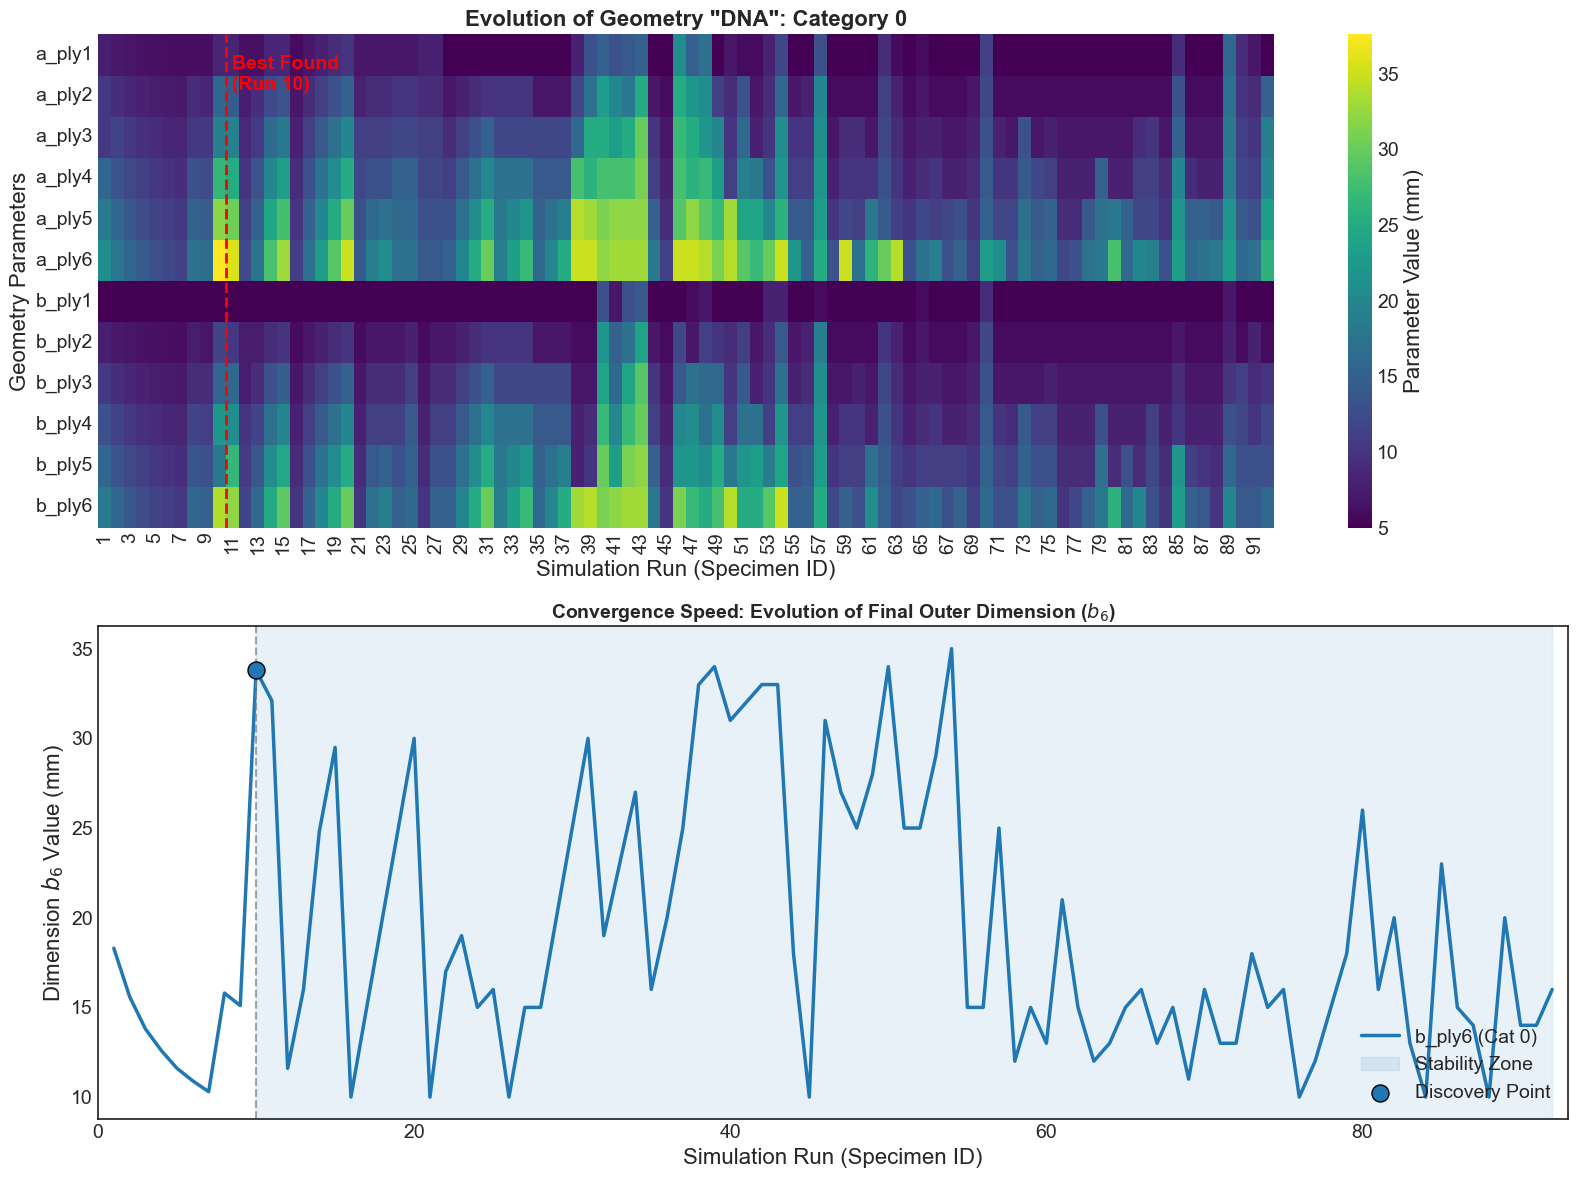


--- Processing Category 1 ---
Plot saved: parameter_evolution_cat1.png


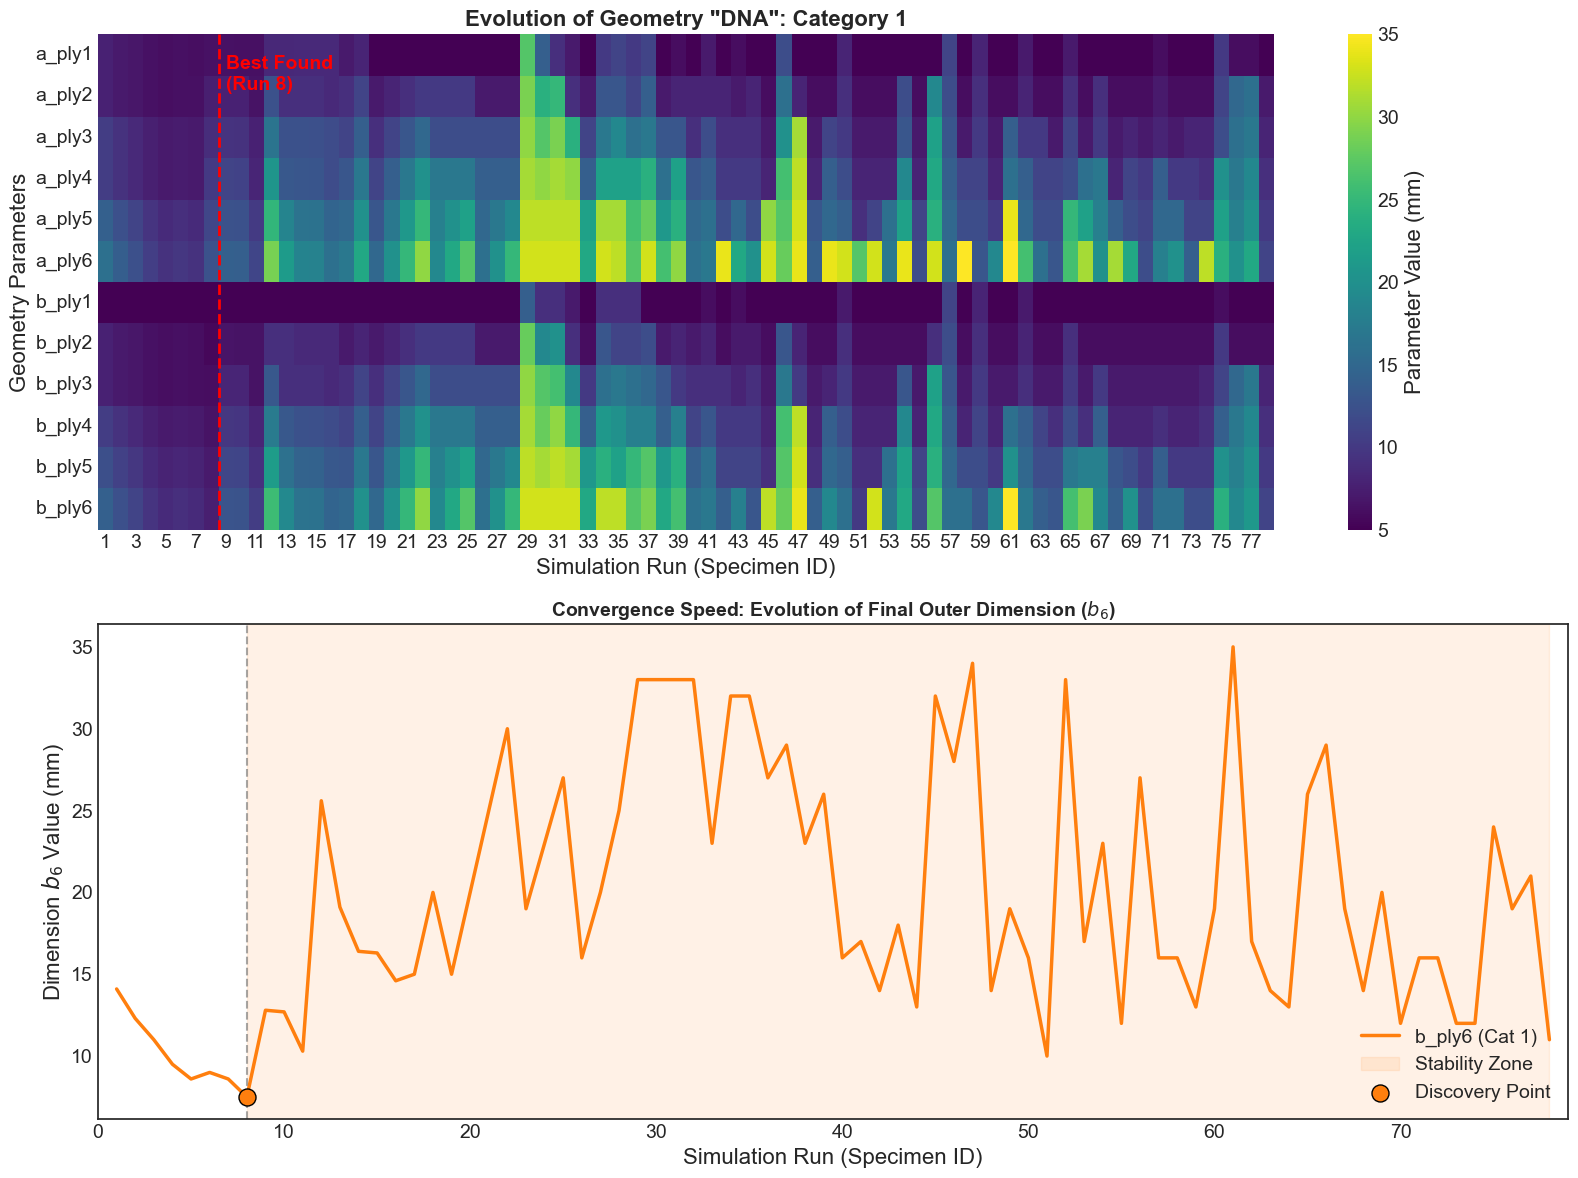

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==========================================
# 0. CONFIG & DATA LOADING
# ==========================================
CATEGORY_IDS = [0, 1] 
SHEET_NAMES = ['Elips0', 'Elips1']
FILE_PATH = 'Data_v4.xlsx'

def load_category_data(file_path, sheet_name, category_id):
    """Loads and preprocesses data for a single category."""
    try:
        # Load Excel Sheet
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        
        # Create 'Run' column based on index
        df['Run'] = np.arange(1, len(df) + 1)
        df['Category'] = f'Cat {category_id}'
        
        return df
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
        return pd.DataFrame()
    except Exception as e:
        print(f"Error loading {sheet_name}: {e}")
        return pd.DataFrame()

def plot_category_evolution(category_id, df):
    """Generates the Heatmap + Convergence plot for a single category."""
    if df.empty:
        print(f"Skipping plot for Category {category_id} (No Data)")
        return

    # --- 1. DATA PREP ---
    # Find Discovery Point (First Strength >= 70)
    try:
        discovery_run = df[df['Strength'] >= 70]['Run'].min()
        if pd.isna(discovery_run): discovery_run = None
    except: 
        discovery_run = None

    # Melt for Heatmap
    param_cols = [f'a_ply{i}' for i in range(1, 7)] + [f'b_ply{i}' for i in range(1, 7)]
    df_melted = df.melt(id_vars=['Run'], value_vars=param_cols, var_name='Param', value_name='Value')
    
    # Pivot for Heatmap
    heatmap_data = df_melted.pivot_table(index='Param', columns='Run', values='Value')
    
    # Reorder index nicely (a1..a6 then b1..b6)
    param_order = [f'a_ply{i}' for i in range(1,7)] + [f'b_ply{i}' for i in range(1,7)]
    heatmap_data = heatmap_data.reindex(param_order)

    # --- 2. PLOTTING ---
    plt.style.use('seaborn-v0_8-white')
    fig = plt.figure(figsize=(16, 12))
    
    # --- SUBPLOT 1: HEATMAP ---
    ax1 = plt.subplot(2, 1, 1)
    sns.heatmap(heatmap_data, cmap='viridis', ax=ax1, cbar_kws={'label': 'Parameter Value (mm)'})
    
    # Annotate Discovery
    if discovery_run:
        ax1.axvline(x=discovery_run, color='red', linestyle='--', linewidth=2)
        ax1.text(discovery_run + 0.5, 0.5, f'Best Found\n(Run {int(discovery_run)})', 
                 color='red', fontweight='bold', va='top')
        
    ax1.set_title(f'Evolution of Geometry "DNA": Category {category_id}', fontsize=16, fontweight='bold')
    ax1.set_xlabel('Simulation Run (Specimen ID)')
    ax1.set_ylabel('Geometry Parameters')

    # --- SUBPLOT 2: CONVERGENCE (b_ply6) ---
    ax2 = plt.subplot(2, 1, 2)
    
    # Data for b_ply6
    df_b6 = df_melted[df_melted['Param'] == 'b_ply6']
    color = '#1f77b4' if category_id == 0 else '#ff7f0e'
    
    sns.lineplot(data=df_b6, x='Run', y='Value', linewidth=2.5, color=color, ax=ax2, label=f'b_ply6 (Cat {category_id})')
    
    # Annotate Discovery & Stability
    if discovery_run:
        ax2.axvline(x=discovery_run, color='grey', linestyle='--', alpha=0.7)
        # Stability Zone
        ax2.axvspan(discovery_run, df['Run'].max(), color=color, alpha=0.1, label='Stability Zone')
        # Marker
        val_at_disc = df.loc[df['Run'] == discovery_run, 'b_ply6'].values[0]
        ax2.scatter(discovery_run, val_at_disc, s=150, c=color, edgecolors='black', zorder=5, label='Discovery Point')

    ax2.set_title('Convergence Speed: Evolution of Final Outer Dimension ($b_6$)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Simulation Run (Specimen ID)')
    ax2.set_ylabel('Dimension $b_6$ Value (mm)')
    ax2.legend(loc='lower right')
    ax2.set_xlim(0, df['Run'].max() + 1)

    plt.tight_layout()
    filename = f'parameter_evolution_cat{category_id}.png'
    plt.savefig(filename)
    print(f"Plot saved: {filename}")
    plt.show()

# ==========================================
# 3. EXECUTION LOOP
# ==========================================
for i, cat_id in enumerate(CATEGORY_IDS):
    print(f"\n--- Processing Category {cat_id} ---")
    df_cat = load_category_data(FILE_PATH, SHEET_NAMES[i], cat_id)
    plot_category_evolution(cat_id, df_cat)


--- Processing Category 0 ---


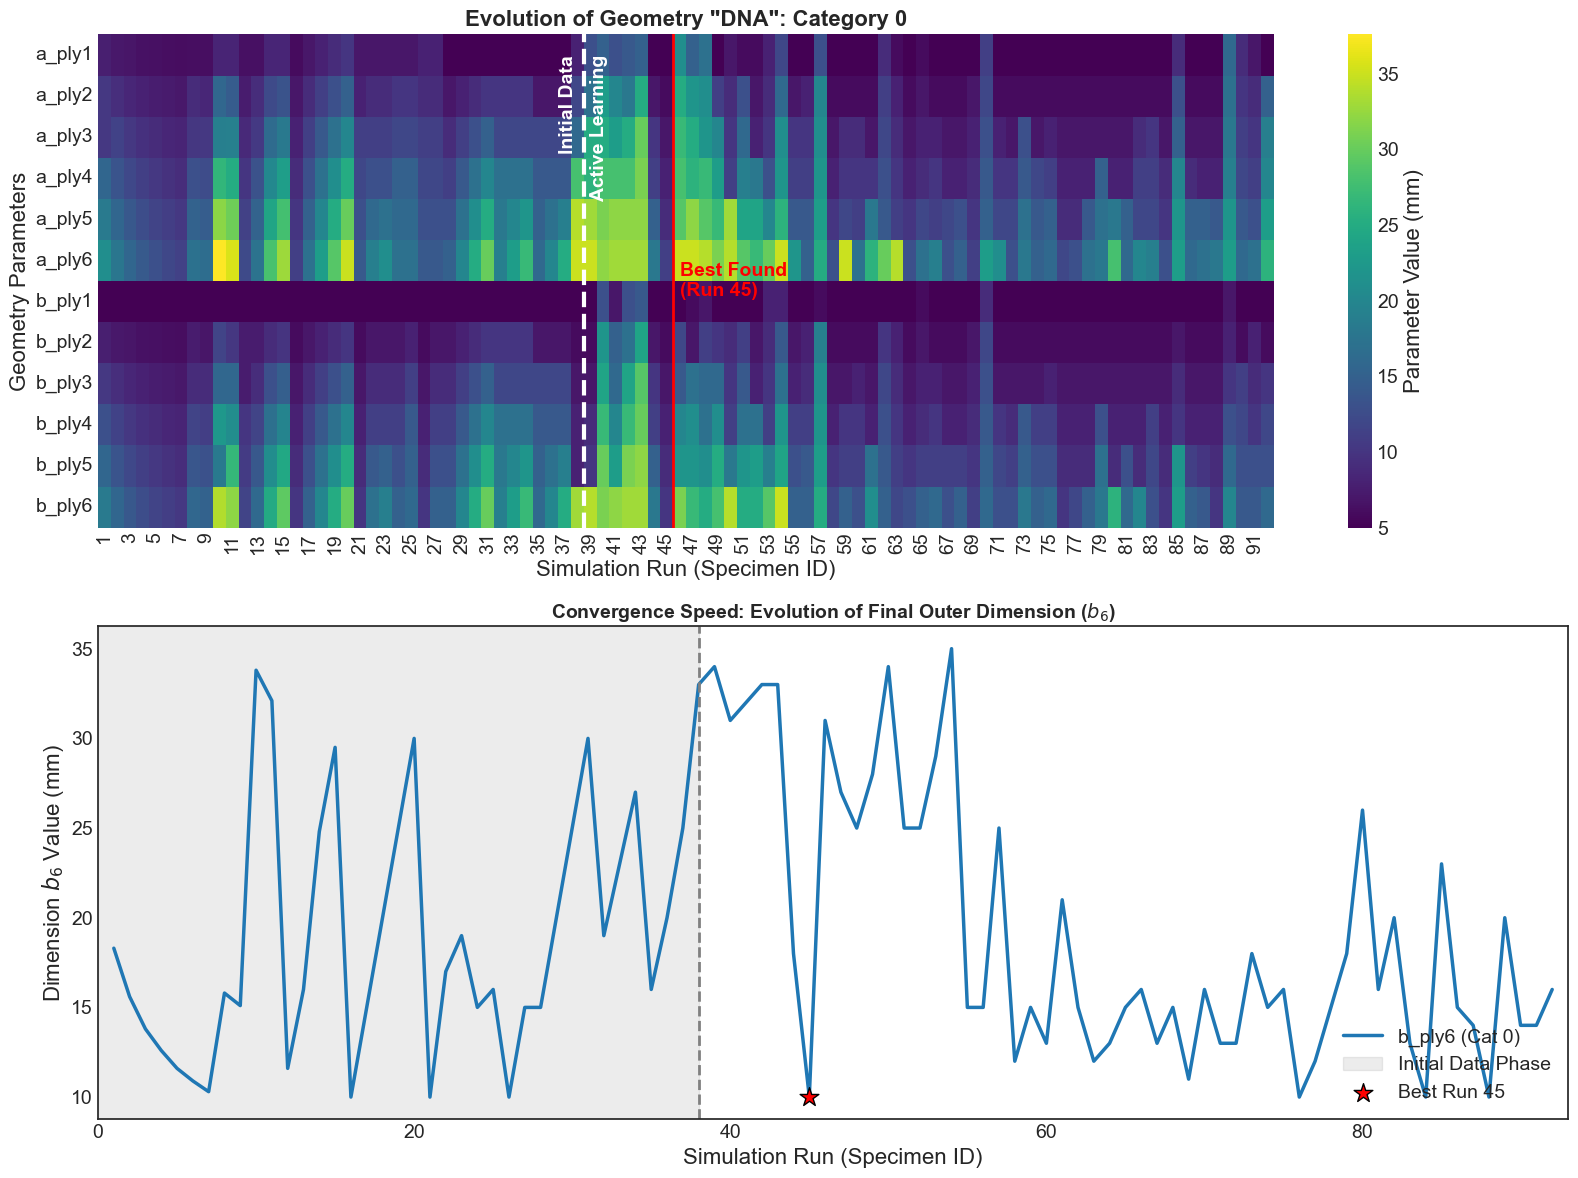


--- Processing Category 1 ---


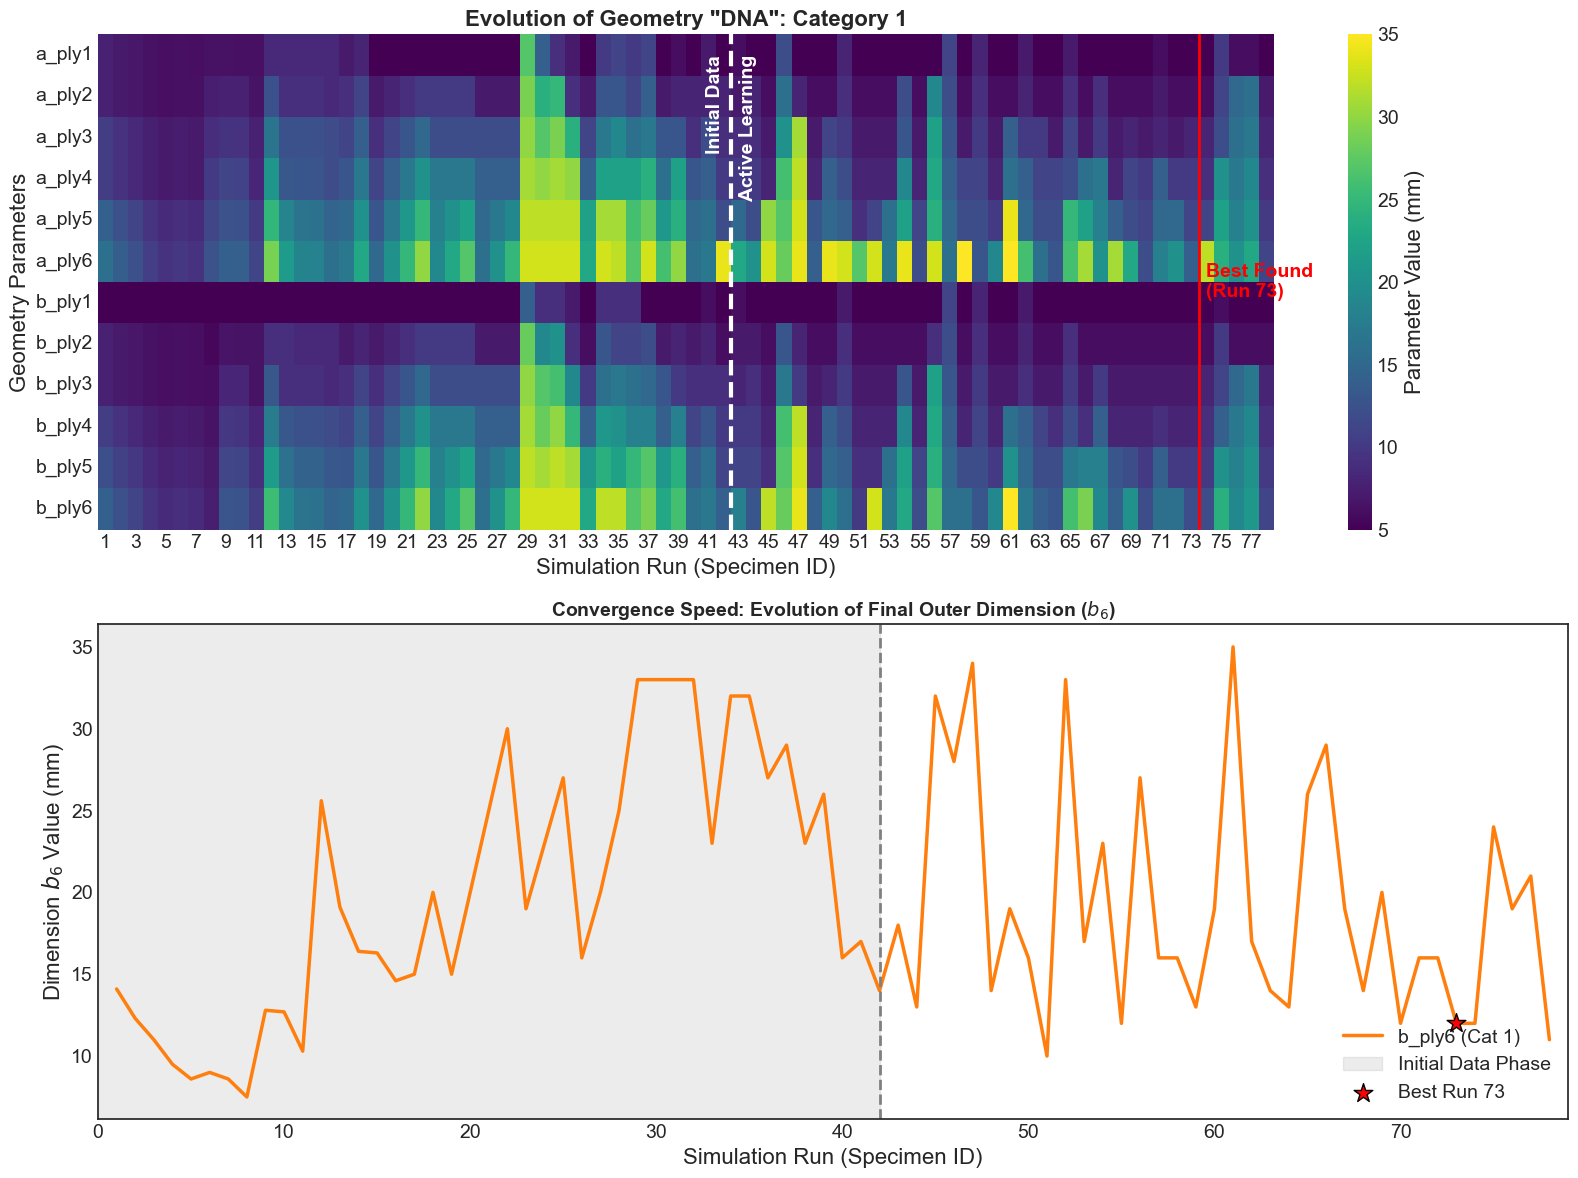

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==========================================
# 0. CONFIG & DATA LOADING
# ==========================================
CATEGORY_IDS = [0, 1] 
SHEET_NAMES = ['Elips0', 'Elips1']
FILE_PATH = 'Data_v4.xlsx'

# User-defined Annotations
INITIAL_RUNS = {0: 38, 1: 42}
BEST_RUNS = {0: 45, 1: 73}

def load_category_data(file_path, sheet_name, category_id):
    """Loads and preprocesses data for a single category."""
    try:
        # Load Excel Sheet
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        
        # Create 'Run' column based on index
        df['Run'] = np.arange(1, len(df) + 1)
        df['Category'] = f'Cat {category_id}'
        
        return df
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
        return pd.DataFrame()
    except Exception as e:
        print(f"Error loading {sheet_name}: {e}")
        return pd.DataFrame()

def plot_category_evolution_refined(category_id, df, initial_count, best_run_id):
    """Generates refined plots with specific annotations."""
    if df.empty:
        print(f"Skipping plot for Category {category_id} (No Data)")
        return

    # --- 1. DATA PREP ---
    # Melt for Heatmap
    param_cols = [f'a_ply{i}' for i in range(1, 7)] + [f'b_ply{i}' for i in range(1, 7)]
    df_melted = df.melt(id_vars=['Run'], value_vars=param_cols, var_name='Param', value_name='Value')
    
    # Pivot for Heatmap
    heatmap_data = df_melted.pivot_table(index='Param', columns='Run', values='Value')
    
    # Reorder index
    param_order = [f'a_ply{i}' for i in range(1,7)] + [f'b_ply{i}' for i in range(1,7)]
    heatmap_data = heatmap_data.reindex(param_order)

    # --- 2. PLOTTING ---
    plt.style.use('seaborn-v0_8-white')
    fig = plt.figure(figsize=(16, 12))
    
    # --- SUBPLOT 1: HEATMAP ---
    ax1 = plt.subplot(2, 1, 1)
    sns.heatmap(heatmap_data, cmap='viridis', ax=ax1, cbar_kws={'label': 'Parameter Value (mm)'})
    
    # Annotation: Initial Data Separation
    ax1.axvline(x=initial_count, color='white', linestyle='--', linewidth=3)
    ax1.text(initial_count - 0.5, 0.5, 'Initial Data', color='white', 
             fontweight='bold', rotation=90, va='top', ha='right')
    ax1.text(initial_count + 0.5, 0.5, 'Active Learning', color='white', 
             fontweight='bold', rotation=90, va='top', ha='left')

    # Annotation: Best Point
    ax1.axvline(x=best_run_id, color='red', linestyle='-', linewidth=2)
    ax1.text(best_run_id + 0.5, 6, f'Best Found\n(Run {best_run_id})', 
             color='red', fontweight='bold', va='center')
        
    ax1.set_title(f'Evolution of Geometry "DNA": Category {category_id}', fontsize=16, fontweight='bold')
    ax1.set_xlabel('Simulation Run (Specimen ID)')
    ax1.set_ylabel('Geometry Parameters')

    # --- SUBPLOT 2: CONVERGENCE (b_ply6) ---
    ax2 = plt.subplot(2, 1, 2)
    
    # Data for b_ply6
    df_b6 = df_melted[df_melted['Param'] == 'b_ply6']
    color = '#1f77b4' if category_id == 0 else '#ff7f0e'
    
    sns.lineplot(data=df_b6, x='Run', y='Value', linewidth=2.5, color=color, ax=ax2, label=f'b_ply6 (Cat {category_id})')
    
    # Shading: Initial Data
    ax2.axvspan(0, initial_count, color='gray', alpha=0.15, label='Initial Data Phase')
    ax2.axvline(x=initial_count, color='gray', linestyle='--', linewidth=2)
    
    # Marker: Best Point
    try:
        val_at_best = df.loc[df['Run'] == best_run_id, 'b_ply6'].values[0]
        ax2.scatter(best_run_id, val_at_best, s=200, c='red', edgecolors='black', marker='*', zorder=10, label=f'Best Run {best_run_id}')
    except IndexError:
        pass 

    ax2.set_title('Convergence Speed: Evolution of Final Outer Dimension ($b_6$)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Simulation Run (Specimen ID)')
    ax2.set_ylabel('Dimension $b_6$ Value (mm)')
    ax2.legend(loc='lower right')
    ax2.set_xlim(0, df['Run'].max() + 1)

    plt.tight_layout()
    plt.savefig(f'parameter_evolution_cat{category_id}_refined.png')
    plt.show()

# ==========================================
# 3. EXECUTION LOOP
# ==========================================
for i, cat_id in enumerate(CATEGORY_IDS):
    print(f"\n--- Processing Category {cat_id} ---")
    df_cat = load_category_data(FILE_PATH, SHEET_NAMES[i], cat_id)
    plot_category_evolution_refined(cat_id, df_cat, INITIAL_RUNS[cat_id], BEST_RUNS[cat_id])